# GFlowNet LET-7 miRNA Sequence Generation (10bp)

FL-DB GFlowNet training on 58 unique LET-7 miRNA sequences (positions 10-19, 10bp variable region) from 612 sequences across 107 species.

In [1]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter

from gfn import train_fast, FastTrainingConfig
from gfn.reward import HammingReward, EntropyWeightedHammingReward, ProgressiveHammingReward

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


## 1. Sliding Window Analysis

Find the optimal 10bp truncation position for maximum sequence diversity.

In [2]:
with open('data/LET7_22bp_targets.json', 'r') as f:
    seqs_22bp = json.load(f)

SEQ_LEN = 22
WINDOW_SIZE = 10

print(f"Total sequences: {len(seqs_22bp)}")
print(f"Window size: {WINDOW_SIZE}bp")
print()

results = []
for start in range(SEQ_LEN - WINDOW_SIZE + 1):
    end = start + WINDOW_SIZE
    truncated = [seq[start:end] for seq in seqs_22bp.values()]
    freq = Counter(truncated)
    n_unique = len(set(truncated))
    max_freq = freq.most_common(1)[0][1]
    entropy = -sum((c/len(truncated)) * np.log2(c/len(truncated)) for c in freq.values())
    
    results.append({'start': start+1, 'end': end, 'n_unique': n_unique, 'entropy': entropy})
    bar = "█" * (n_unique // 2)
    print(f"Position {start+1:2d}-{end:2d}: {n_unique:3d} unique | entropy={entropy:.2f} | {bar}")

best = max(results, key=lambda x: x['n_unique'])
print(f"\nBest: Position {best['start']}-{best['end']} with {best['n_unique']} unique sequences")

Total sequences: 612
Window size: 10bp

Position  1-10:  17 unique | entropy=1.12 | ████████
Position  2-11:  20 unique | entropy=1.15 | ██████████
Position  3-12:  29 unique | entropy=2.26 | ██████████████
Position  4-13:  29 unique | entropy=2.26 | ██████████████
Position  5-14:  31 unique | entropy=2.27 | ███████████████
Position  6-15:  33 unique | entropy=2.38 | ████████████████
Position  7-16:  38 unique | entropy=2.75 | ███████████████████
Position  8-17:  44 unique | entropy=3.30 | ██████████████████████
Position  9-18:  50 unique | entropy=3.45 | █████████████████████████
Position 10-19:  58 unique | entropy=3.76 | █████████████████████████████
Position 11-20:  47 unique | entropy=3.51 | ███████████████████████
Position 12-21:  46 unique | entropy=3.46 | ███████████████████████
Position 13-22:  41 unique | entropy=3.09 | ████████████████████

Best: Position 10-19 with 58 unique sequences


## 2. Load LET-7 Target Sequences

## 2.1 Species and Sequence Distribution

In [3]:
with open('data/LET7_10bp_targets.json', 'r') as f:
    TARGET_SEQUENCES_DICT = json.load(f)

def get_species(mirna_name):
    """Extract species code, e.g. 'Hsa' from 'Hsa-Let-7-P2b3_5p'."""
    return mirna_name.split('-')[0]

species_to_mirnas = {}
for mirna_name, seq in TARGET_SEQUENCES_DICT.items():
    species = get_species(mirna_name)
    if species not in species_to_mirnas:
        species_to_mirnas[species] = []
    species_to_mirnas[species].append((mirna_name, seq))

seq_to_species = {}
for mirna_name, seq in TARGET_SEQUENCES_DICT.items():
    species = get_species(mirna_name)
    if seq not in seq_to_species:
        seq_to_species[seq] = set()
    seq_to_species[seq].add(species)

print(f"{'Rank':<5} {'Sequence':<12} {'#Species':<10} {'Species List (first 10)'}")
print("-"*70)

seq_species_ranked = sorted(seq_to_species.items(), key=lambda x: len(x[1]), reverse=True)
for rank, (seq, species_set) in enumerate(seq_species_ranked, 1):
    species_list = sorted(species_set)
    species_str = ', '.join(species_list[:10])
    if len(species_list) > 10:
        species_str += f", ... (+{len(species_list)-10} more)"
    print(f"{rank:<5} {seq:<12} {len(species_set):<10} {species_str}")

print(f"\n{len(seq_to_species)} unique sequences across {len(species_to_mirnas)} species")

Rank  Sequence     #Species   Species List (first 10)
----------------------------------------------------------------------
1     AGGUUGUAUA   83         Aca, Agr, Ami, Asu, Bfl, Bge, Bla, Bta, Cbr, Cel, ... (+73 more)
2     AGGUUGUAUG   38         Aca, Ami, Bta, Cfa, Cja, Cli, Cpi, Cpo, Dma, Dno, ... (+28 more)
3     AGAUUGUAUA   37         Aca, Ami, Bta, Cfa, Cja, Cli, Cmi, Cpi, Cpo, Dno, ... (+27 more)
4     AGGUUGUGUG   35         Aca, Ami, Bta, Cfa, Cja, Cpi, Cpo, Dno, Dre, Eca, ... (+25 more)
5     AGUUUGUGCU   35         Aca, Ami, Bta, Cfa, Cja, Cpi, Cpo, Dno, Dre, Eca, ... (+25 more)
6     AGGUUGCAUA   31         Aca, Ami, Bta, Cfa, Cja, Cli, Cmi, Cpi, Cpo, Dno, ... (+21 more)
7     AGUUUGUACA   29         Aca, Ami, Bta, Cfa, Cja, Cli, Cpi, Cpo, Dno, Eca, ... (+19 more)
8     AAGUUGUAUU   23         Aca, Bta, Cfa, Cja, Cpo, Dno, Eca, Ete, Gja, Hsa, ... (+13 more)
9     AGAUUGAAUA   17         Aca, Ami, Cli, Cpi, Dre, Gga, Gja, Gmo, Lch, Loc, ... (+7 more)
10    UGGUUGUAUG   8 

In [4]:
species_ranked = sorted(species_to_mirnas.items(), key=lambda x: len(x[1]), reverse=True)

print(f"{'Rank':<5} {'Species':<8} {'#miRNAs':<10} {'Unique Seqs':<12} {'Sequences'}")
print("-"*70)

for rank, (species, mirna_list) in enumerate(species_ranked, 1):
    seqs = [seq for _, seq in mirna_list]
    unique_seqs = set(seqs)
    seq_str = ', '.join(sorted(unique_seqs)[:3])
    if len(unique_seqs) > 3:
        seq_str += f", ... (+{len(unique_seqs)-3})"
    print(f"{rank:<5} {species:<8} {len(mirna_list):<10} {len(unique_seqs):<12} {seq_str}")

mirna_counts = [len(v) for v in species_to_mirnas.values()]
print(f"\nTotal species: {len(species_to_mirnas)}")
print(f"Total miRNAs: {sum(mirna_counts)}")
print(f"miRNAs per species: min={min(mirna_counts)}, max={max(mirna_counts)}, mean={np.mean(mirna_counts):.1f}")

Rank  Species  #miRNAs    Unique Seqs  Sequences
----------------------------------------------------------------------
1     Dre      21         10           AAGUUGUGUU, AGAUUGAAUA, AGAUUGUAUA, ... (+7)
2     Gmo      20         11           AAGUUGUGUU, AGAUUGAAUA, AGAUUGUAUA, ... (+8)
3     Mal      20         10           AAGUUGUGUU, AGAUUGAAUA, AGAUUGUAUA, ... (+7)
4     Tni      19         8            AAGUUGUGUU, AGAUUGAAUA, AGGUUGUAUA, ... (+5)
5     Xla      17         9            AAGUUGUAUU, AGAUUGUAUA, AGGUUGUAUA, ... (+6)
6     Mun      15         11           AAGUUGUAUU, AGAUUGAAUA, AGAUUGUAUG, ... (+8)
7     Aca      14         9            AAGUUGUAUU, AGAUUGAAUA, AGAUUGUAUA, ... (+6)
8     Ami      14         9            AAGUUGUAUC, AGAUUGAAUA, AGAUUGUAUA, ... (+6)
9     Cpi      14         9            ACGUUGUAUU, AGAUUGAAUA, AGAUUGUAUA, ... (+6)
10    Gja      14         9            AAGUUGUAUU, AGAUUGAAUA, AGAUUGUAUA, ... (+6)
11    Lch      14         10           A

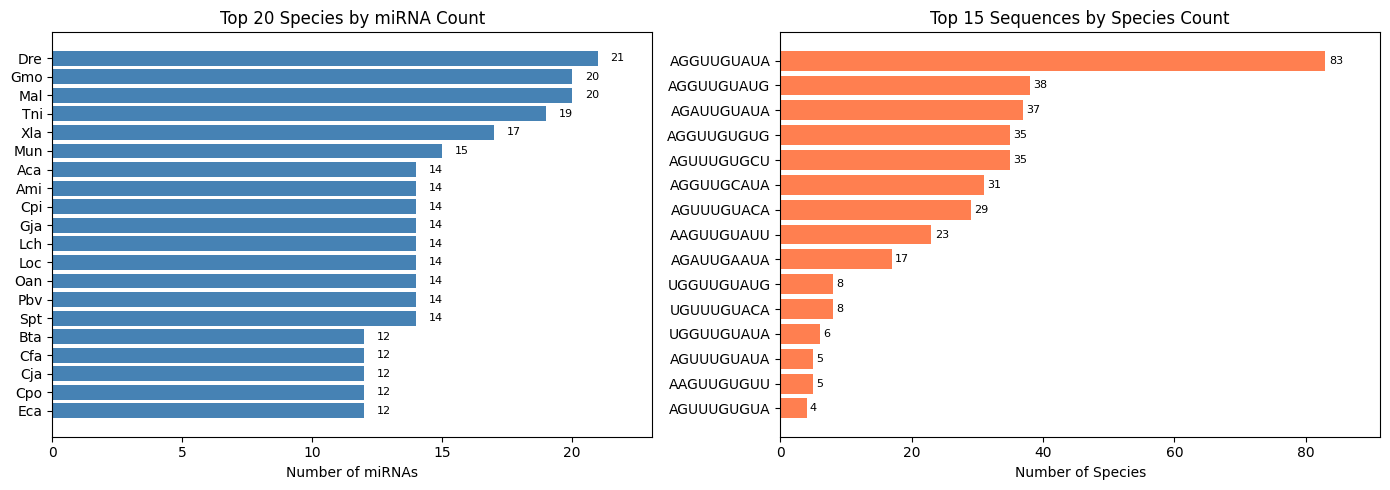


AGGUUGUAUA is the most conserved sequence, found in 83 species


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
top_species = species_ranked[:20]
species_names = [s for s, _ in top_species]
mirna_counts_top = [len(m) for _, m in top_species]
bars = ax1.barh(species_names[::-1], mirna_counts_top[::-1], color='steelblue')
ax1.set_xlabel('Number of miRNAs')
ax1.set_title('Top 20 Species by miRNA Count')
ax1.set_xlim(0, max(mirna_counts_top) * 1.1)
for bar, count in zip(bars, mirna_counts_top[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=8)

ax2 = axes[1]
top_seqs = seq_species_ranked[:15]
seq_names = [s for s, _ in top_seqs]
species_counts = [len(sp) for _, sp in top_seqs]
bars = ax2.barh(seq_names[::-1], species_counts[::-1], color='coral')
ax2.set_xlabel('Number of Species')
ax2.set_title('Top 15 Sequences by Species Count')
ax2.set_xlim(0, max(species_counts) * 1.1)
for bar, count in zip(bars, species_counts[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nAGGUUGUAUA is the most conserved sequence, found in {len(seq_to_species['AGGUUGUAUA'])} species")

In [6]:
import importlib
import data.LET7_10bp_targets
importlib.reload(data.LET7_10bp_targets)
from data.LET7_10bp_targets import TARGET_SEQUENCES_LIST, TARGET_SEQUENCES_DICT

target_sequences = TARGET_SEQUENCES_LIST

print(f"Number of unique targets: {len(target_sequences)}")
print(f"Target hit probability (random): {len(target_sequences) / 4**10 * 100:.6f}%")
print(f"\nAll {len(target_sequences)} target sequences:")
for i, seq in enumerate(target_sequences):
    print(f"  {i+1:2d}. {seq}")

Number of unique targets: 58
Target hit probability (random): 0.005531%

All 58 target sequences:
   1. AAGUUGUAUA
   2. AAGUUGUAUC
   3. AAGUUGUAUU
   4. AAGUUGUGUU
   5. ACGUUGUAUU
   6. AGAUUGAAUA
   7. AGAUUGUAUA
   8. AGAUUGUAUG
   9. AGAUUGUUUA
  10. AGGCUAUCUC
  11. AGGUUAUAUA
  12. AGGUUAUAUU
  13. AGGUUAUGCA
  14. AGGUUAUGUA
  15. AGGUUCCAUA
  16. AGGUUGCAUA
  17. AGGUUGUAAA
  18. AGGUUGUACA
  19. AGGUUGUAUA
  20. AGGUUGUAUG
  21. AGGUUGUAUU
  22. AGGUUGUGUA
  23. AGGUUGUGUG
  24. AGGUUGUUUA
  25. AGGUUUGUUA
  26. AGGUUUUGUA
  27. AGUUUGUACA
  28. AGUUUGUAUA
  29. AGUUUGUGCU
  30. AGUUUGUGUA
  31. AGUUUGUGUU
  32. AUGUUGGAUG
  33. CGGUUGCGUA
  34. CGGUUGUAAA
  35. CGGUUGUAUA
  36. GACUCAAAAG
  37. GAGUUGUAUA
  38. GAUUCAAAAA
  39. GAUUUGUGUA
  40. GGAUUCUGUA
  41. GGGUUGCAUA
  42. GGGUUGUAUA
  43. GGUUUGUGUA
  44. GUGAUAAACA
  45. GUGUAAGACA
  46. GUGUUGUAGA
  47. GUUUCGAAUG
  48. UAAUUGGAUG
  49. UAGGUUAUGU
  50. UCGUUGUGUG
  51. UGAUUGUGUG
  52. UGGUAGUAUG
  53. UGGUUGUAUA
 

In [7]:
seq_counts = Counter(TARGET_SEQUENCES_DICT.values())
print("Sequence frequency (by species count):")
for seq, count in seq_counts.most_common():
    pct = count / len(TARGET_SEQUENCES_DICT) * 100
    bar = "█" * int(pct / 2)
    print(f"{seq}: {count:3d} ({pct:5.1f}%) {bar}")

Sequence frequency (by species count):
AGGUUGUAUA: 208 ( 34.0%) ████████████████
AGAUUGUAUA:  64 ( 10.5%) █████
AGGUUGUAUG:  53 (  8.7%) ████
AGGUUGUGUG:  39 (  6.4%) ███
AGUUUGUGCU:  37 (  6.0%) ███
AGGUUGCAUA:  31 (  5.1%) ██
AGUUUGUACA:  29 (  4.7%) ██
AAGUUGUAUU:  24 (  3.9%) █
AGAUUGAAUA:  21 (  3.4%) █
UGGUUGUAUG:  12 (  2.0%) 
AGUUUGUAUA:   9 (  1.5%) 
UGUUUGUACA:   9 (  1.5%) 
AAGUUGUGUU:   7 (  1.1%) 
UGGUUGUAUA:   6 (  1.0%) 
AGGUUGUUUA:   6 (  1.0%) 
AGUUUGUGUA:   4 (  0.7%) 
AGGUUGUAUU:   2 (  0.3%) 
AGGUUGUACA:   2 (  0.3%) 
AGAUUGUAUG:   2 (  0.3%) 
AGGUUGUGUA:   2 (  0.3%) 
AGUUUGUGUU:   2 (  0.3%) 
AGGUUAUGCA:   2 (  0.3%) 
AGGUUAUAUU:   2 (  0.3%) 
AGGUUGUAAA:   2 (  0.3%) 
AUGUUGGAUG:   2 (  0.3%) 
UUGUUGGAUG:   2 (  0.3%) 
AGGUUUGUUA:   2 (  0.3%) 
GUUUCGAAUG:   1 (  0.2%) 
GUGUUGUAGA:   1 (  0.2%) 
GAGUUGUAUA:   1 (  0.2%) 
GUGAUAAACA:   1 (  0.2%) 
CGGUUGCGUA:   1 (  0.2%) 
GAUUUGUGUA:   1 (  0.2%) 
UGAUUGUGUG:   1 (  0.2%) 
CGGUUGUAAA:   1 (  0.2%) 
UCGUUGUGUG:   

## 3. FL-DB Training Configuration

In [8]:
# Environment settings
SEQ_LEN = 10
ALPHABET = ['A', 'U', 'G', 'C']

print(f"Sequence length: {SEQ_LEN}bp")
print(f"Alphabet: {ALPHABET}")
print(f"State space: 4^{SEQ_LEN} = {4**SEQ_LEN:,}")
print(f"Targets: {len(target_sequences)} unique sequences")

Sequence length: 10bp
Alphabet: ['A', 'U', 'G', 'C']
State space: 4^10 = 1,048,576
Targets: 58 unique sequences


In [9]:
# # Reward function: Entropy-weighted Hamming distance
# # This boosts rewards for more complex/rare sequences
# reward_fn = EntropyWeightedHammingReward(
#     target_sequences,
#     alphabet=ALPHABET,
#     r_min=0.1,
#     device='cuda',
#     entropy_weight=1.0,
# )
# print(f"Reward: EntropyWeightedHammingReward")
# print(f"GPU batch support: {reward_fn.supports_batch}")

In [10]:
from gfn.reward import ProgressiveHammingReward

reward_fn = ProgressiveHammingReward(
    target_sequences=target_sequences,
    alphabet=ALPHABET,
    r_min=0.01,
    device='cuda',
    prefix_boost=0.0,
    prefix_decay=0.0,
)

In [11]:
config = FastTrainingConfig(
    alphabet=ALPHABET,
    max_seq_len=SEQ_LEN,
    seed=42,
    hidden_layers=[64, 64, 32],
    batch_size=1024,
    n_iterations=500,
    learning_rate=3e-3,
    device='cuda',
    objective='FLDB',
    target_sequences=target_sequences,
    explore_ratio=0.3,
    temperature=2.0,
    insert_only=True,
)

print("FL-DB Configuration:")
print(f"  Sequence: {config.max_seq_len}bp")
print(f"  Total episodes: {config.batch_size * config.n_iterations:,}")
print(f"  Hidden layers: {config.hidden_layers}")
print(f"  Exploration: eps={config.explore_ratio}, T={config.temperature}")

FL-DB Configuration:
  Sequence: 10bp
  Total episodes: 512,000
  Hidden layers: [64, 64, 32]
  Exploration: eps=0.3, T=2.0


## 4. Train FL-DB Model

In [12]:
start_time = time.time()
result = train_fast(reward_fn, config, verbose=True)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f}s")
print(f"Final Z (log F(s0)) = {result.final_Z:.2f}")
if result.hit_rates:
    print(f"Final Hit Rate = {result.final_hit_rate*100:.4f}%")
if result.target_coverages:
    print(f"Target Coverage = {result.n_unique_targets_hit}/{result.n_targets}")

Fast FL-DB Training: 100%|██████████| 500/500 [05:59<00:00,  1.39it/s]


Training completed in 359.85s
Final Z (log F(s0)) = 5334.28
Final Hit Rate = 0.0000%
Target Coverage = 24/58


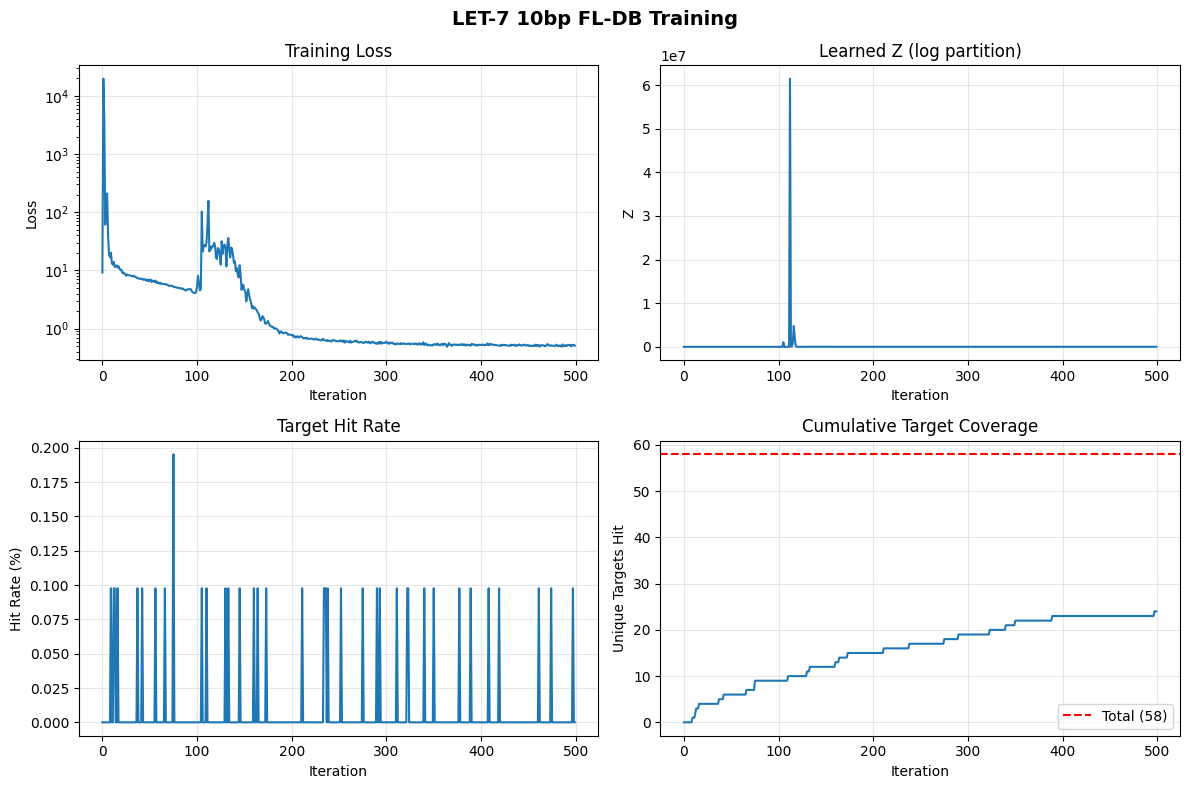

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(result.losses)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(np.exp(result.logZs))
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Z')
axes[0, 1].set_title('Learned Z (log partition)')
axes[0, 1].grid(True, alpha=0.3)

if result.hit_rates:
    axes[1, 0].plot([hr*100 for hr in result.hit_rates])
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Hit Rate (%)')
    axes[1, 0].set_title('Target Hit Rate')
    axes[1, 0].grid(True, alpha=0.3)

if result.target_coverages:
    n_tgt = len(target_sequences)
    coverage_counts = [c * n_tgt for c in result.target_coverages]
    axes[1, 1].plot(coverage_counts)
    axes[1, 1].axhline(y=n_tgt, color='r', linestyle='--', 
                       label=f'Total ({n_tgt})')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Unique Targets Hit')
    axes[1, 1].set_title('Cumulative Target Coverage')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('LET-7 10bp FL-DB Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/LET7_10bp_fldb_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample Generated Sequences

In [14]:
print("FL-DB Model (last 20 samples):")
for state in result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε')
    is_target = seq in target_sequences
    marker = " <- TARGET" if is_target else ""
    print(f"  {seq}{marker}")
    
print(f"\nTotal sampled states: {len(result.sampled_states)}")

FL-DB Model (last 20 samples):
  AUUAGCCUUU
  AACAGUAAAU
  UAGCUCGAGC
  GAGUGUGCAC
  UUGAAGGACU
  CCAUUUGUCU
  ACGCCAUCAG
  UCGAUUACAC
  UAGUCCUACA
  GUAGCGUGUA
  UCUUGACAUU
  AAGGGUGGUC
  CGCGGAGUUU
  CCGUACUAUG
  UGUGGCGAUC
  CGUUCAGGAA
  GUUCAGCACG
  UACUGUGCAC
  GCUGUGGUGU
  GUUCUAGAAU

Total sampled states: 5000


In [15]:
from collections import Counter

samples = []
for state in result.sampled_states:
    seq = ''.join(s for s in state[1] if s != 'ε')
    samples.append(seq)

n_samples = len(samples)
sample_counts = Counter(samples)

print(f"Total samples from training: {n_samples}")
print(f"Unique sequences: {len(sample_counts)}")

Total samples from training: 5000
Unique sequences: 4990


In [16]:
target_set = set(target_sequences)

print("Top 20 Generated Sequences:")
for seq, count in sample_counts.most_common(20):
    is_target = "<- TARGET" if seq in target_set else ""
    print(f"  {seq}: {count:4d} ({count/n_samples*100:5.1f}%) {is_target}")

n_hits = sum(1 for s in samples if s in target_set)
print(f"\nTarget hit rate: {n_hits}/{n_samples} = {n_hits/n_samples*100:.2f}%")

Top 20 Generated Sequences:
  UGGGGGGGGU:    2 (  0.0%) 
  GGAACUUUGU:    2 (  0.0%) 
  CCGCCGGGAG:    2 (  0.0%) 
  UCGUUCACAC:    2 (  0.0%) 
  UAACGGAAUU:    2 (  0.0%) 
  UUUGCAAUCA:    2 (  0.0%) 
  UGGCCCCAAC:    2 (  0.0%) 
  AGGCGUCGUA:    2 (  0.0%) 
  UUGUCGUGGG:    2 (  0.0%) 
  AUGGUCAUGU:    2 (  0.0%) 
  UACGCGAGGU:    1 (  0.0%) 
  GAGACCACGU:    1 (  0.0%) 
  AGCAGUCGUC:    1 (  0.0%) 
  CACGCUUGCU:    1 (  0.0%) 
  CAGAAAAUUA:    1 (  0.0%) 
  CGGCACAGAG:    1 (  0.0%) 
  UCGUGGCGUA:    1 (  0.0%) 
  CUCGCGGGAC:    1 (  0.0%) 
  GGCUUUGUCC:    1 (  0.0%) 
  GGGUGACGCG:    1 (  0.0%) 

Target hit rate: 1/5000 = 0.02%


## 7. Save Results

In [ ]:
import pickle
import os
from datetime import datetime

os.makedirs('results', exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

torch.save(result.model.state_dict(), f'results/LET7_10bp_FLDB_model_{timestamp}.pt')

results_data = {
    'losses': result.losses,
    'logZs': result.logZs,
    'hit_rates': result.hit_rates,
    'target_coverages': result.target_coverages,
    'hit_trajectories': [h.to_dict() for h in result.hit_trajectories] if result.hit_trajectories else [],
    'training_time': training_time,
    'samples': samples,
    'config': {
        'seq_len': SEQ_LEN,
        'n_targets': len(target_sequences),
        'batch_size': config.batch_size,
        'n_iterations': config.n_iterations,
    },
}

with open(f'results/LET7_10bp_FLDB_results_{timestamp}.pkl', 'wb') as f:
    pickle.dump(results_data, f)

print(f"Saved with timestamp: {timestamp}")
print(f"  Model: results/LET7_10bp_FLDB_model_{timestamp}.pt")
print(f"  Results: results/LET7_10bp_FLDB_results_{timestamp}.pkl")

Saved with timestamp: 20260306_210233
  Model: results/LET7_10bp_FLDB_model_20260306_210233.pt
  Results: results/LET7_10bp_FLDB_results_20260306_210233.pkl


: 